# TransC Ensemble Resampler applied to AEM Lagrange dataset - single layered model

This example demonstrates the use of the Trans-C Ensemble Resampler on a real Airborne EM dataset and compares results to a Trans_D sampler.

### Problem setup

The Earth model is a layered 1D profile of log conductivities.

<div style="text-align: center;">
<img src="./AEM_data/Layer_param.png" alt="1D Later Parameterization" width="300"/>
</div>

10 independent states are used such that state $k$, ($k=0,\dots,9$) has $k$ variable depth layers and $k$ log-conductivities over a halfspace whose conductivity is also allowed to vary, making $2k+1$ unknowns.

This notebook has two modes of operation:
   - Posterior ensembles of models are read in and sampled over with the *Ensemble Resampler* (to find relative evdience of each state);
   - Prior ensembles of models are generated and sampled over with the *Ensemble Resampler* (to recover the known prior over states).

It also has two options for defining the pseudo prior:
- Use a simple normalized uniform distribution between bounds for each state;
- Fit a mixture model to the input posterior ensembles in each state. This is achieved with the utility routine `build_auto_pseudo_prior()`
    
Trans-D ensembles may be generated and results compared to a Reversible-Jump solution produced by Ross Brodie's code (https://github.com/GeoscienceAustralia/ga-aem)

In [1]:
# standard libraries
import time
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import math
from IPython.display import display
from PIL import Image
from tqdm import tqdm
from utils.AEM_IO_utils import (
    create_InferenceData_object,
    read_aem_ensembles,
    setproposalweights,
)
from utils.AEM_plot_utils import plot_ensembles, plot_histogram_is, plot_pseudo_samples

#### TransC class

In [2]:
from pytransc.analysis.samples import resample_ensembles
from pytransc.analysis.visits import (
    count_state_changes,
    count_total_state_changes,
    get_acceptance_rate_between_states,
    get_autocorr_between_state_jumps,
    get_relative_marginal_likelihoods,
    get_visits_to_states,
)
from pytransc.samplers import run_ensemble_resampler
from pytransc.pseudoprior import build_auto_pseudo_prior

#### Utilities

In [3]:
def log_factorial(n):
  """
  Calculates the natural logarithm of n! (n factorial).

  Args:
    n: A non-negative integer.

  Returns:
    The natural logarithm of n!.
  """
  if n < 0:
    raise ValueError("n must be a non-negative integer")
  return math.lgamma(n + 1)

#### Read posterior ensembles for each state

Here we read in pre-computed posterior samples for each of the 10 states, together with their log-posterior values (unnormalized). These 25000 models were obtained using an MCMC sampler applied separately to each state. The input ensembles only have log-Likelihood values attached (without their prior). 

In [4]:
# read in enembles
ensemble_per_state_posterior, log_likelihood_ens, nstates, ndims, nens = read_aem_ensembles(
    "AEM_data"
)
print("Number of states: ", nstates)
print("Size of ensemble in each state", nens)
print("Number of parameters in each state", ndims)

Number of states:  10
Size of ensemble in each state 25000
Number of parameters in each state [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


#### The prior for each state

For this layered paramterization a convenient prior is a uniform distribution within bounds in each state, suitably normalized so that its integral within those bounds is unity.

$$
\phi({\bf m}^{(k)}) = \frac{k!}{(\Delta Z)^{k} (\Delta C)^{k+1}}, \quad (k=0,\dots 9)
$$

where ${\bf m}^{(k)}$ indicates a model in state $k$ which has $k$ layers/interfaces, $\Delta Z$ represents the depth range over which the interfaces are created (500 m), $\Delta C$ is the range in log-conductivities [$\log_{10}(0.001), \log_{10}(5)]$ or $[-3,0.69] \log_{10}$ S/m, and the factorial enters because there are $k!$ ways of ordering the interfaces. A corner plot of an ensemble of $10^5$ random models generated from the prior of the 5th state are plotted below. 

In [5]:
# prior for layered conductiviy model with variable interface depths and layer conductivities
bounds = [0, 500, 0.001, 5.0]                                       # parameter bounds (zmin,zmax,logc_min,logc_max)
prior_int = [log_factorial(k) for k in range(10)]                   # prior numerator
dz = bounds[1]-bounds[0]                                            # range of interface depths
dc = bounds[3]-bounds[2]                                            # range of log-conductivities
log_prior_den = [prior_int[k]- k*np.log(dz) - (k+1)*np.log(dc) for k in range(10)] # prior density in each state
#
def log_prior(x, state, ndims, bounds, returndeviate=False): 
    """Log prior for each 1D model with uniform random interfaces and log conductivoties with each layer"""

    ncond = ndims[state] - state  # number of conductivities
    ndepth = state  # number of interfaces
    rng = np.random.default_rng()
    
    if returndeviate: # we are returning a random deviate generated from the prior
        zmin, zmax, logcmin, logcmax = bounds
        z = np.sort(zmin + (zmax - zmin) * rng.uniform(size=ndepth))
        logc = logcmin + (logcmax - logcmin) * rng.uniform(size=ncond)
        if state == 0:
            x = logc
        else:
            x = np.hstack((z, logc))
        return log_prior_den[state], x # return prior density and random deviate from prior
    else:
        if x.ndim == 1:
            return log_prior_den[state]*np.ones(len(x))  # return prior density for each input model
        if x.ndim == 2:
            return log_prior_den[state]*np.ones(np.shape(x)[0])  # return prior density for each input model

#### Choose ensemble type for each state

We have the option of using the posterior ensembles read in or a prior ensemble calculated here.

In [6]:
ensemble_type = 'prior'     # we are applying the Ensemble Resampler to a set of prior ensembles
ensemble_type = 'posterior' # we are applying the Ensemble Resampler to the posterior ensembles read in

if(ensemble_type == 'prior'): 
    ensemble_per_state_prior,log_prior_ens = [],[]
    for state in range(nstates): # calculate the prior ensemble
        logp = np.zeros(nens)
        x = np.zeros((nens,ndims[state]))
        for i in range(nens):
            logp[i],x[i] = log_prior(None,state,ndims, bounds, returndeviate=True)
        ensemble_per_state_prior.append(x)
        log_prior_ens.append(logp)
    ensemble_per_state = ensemble_per_state_prior
    log_posterior_ens = log_prior_ens

else: # add log priors to posterior ensemble (because the input values are just log-likelihoods)

    ensemble_per_state = ensemble_per_state_posterior
    log_posterior_ens,log_prior_ens = [],[]
    for state in range(nstates):
        logp = log_prior(ensemble_per_state_posterior[state],state,ndims, bounds)
        log_prior_ens.append(logp)
        log_posterior_ens.append(log_likelihood_ens[state]+logp)

#### Plot input ensembles for reference

We take a quick look at the input ensembles of models witha  corner plot. 

Here we plot the 5th ensemble which has 5 layers, with 4 interface depths and 5 conductivities. 

In [7]:
azdata = create_InferenceData_object(
    ensemble_per_state, log_posterior_ens, log_likelihood=None
)  # create list of arviz objetcs to help with plotting

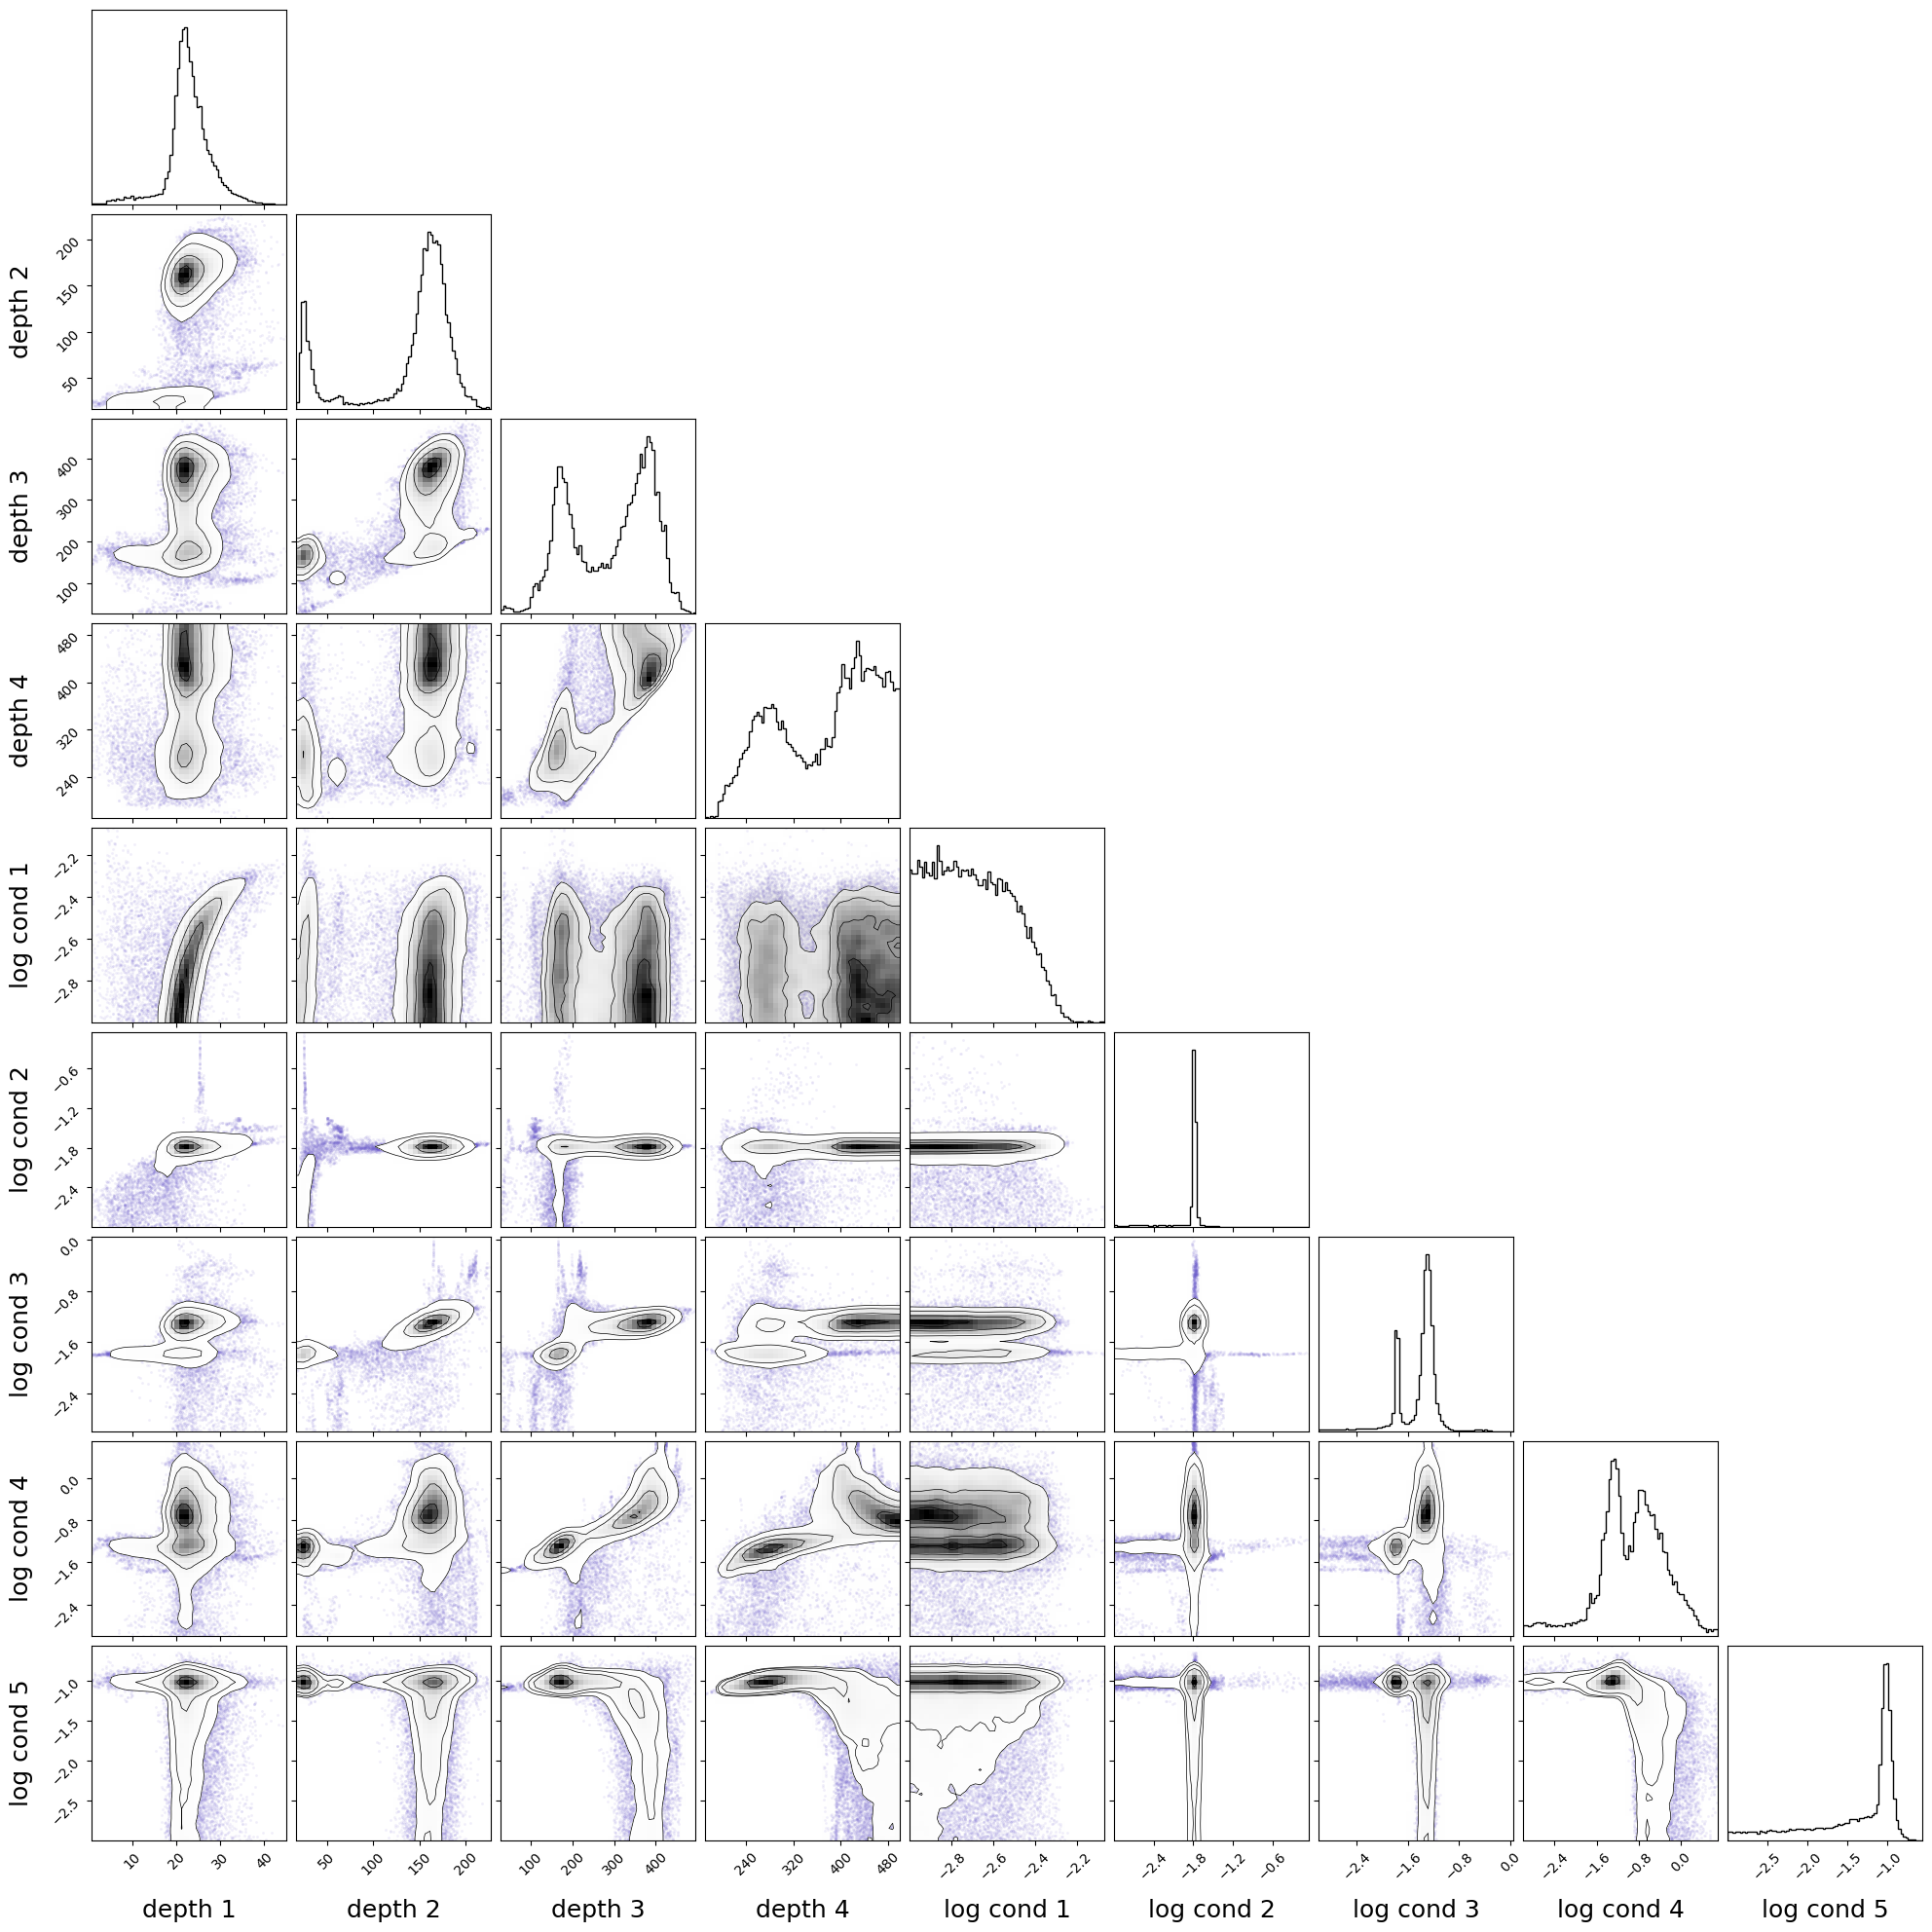

In [8]:
state = 4
label_kwargs = {"fontsize": 18}
plot_ensembles(
    azdata[state], traceplot=False, label_kwargs=label_kwargs
)  # corner plot and traceplot of input ensemble in selected state

The posterior ensembles look to have some non-Gaussian structure.

#### Build pseudo priors

We have a choice of pseudo prior. Either set equal to the prior (`pseudoprior = "prior"`), or fit a mixture model to the given ensembles (`pseudoprior = "auto"`).

In [9]:
# create pseudo prior function and evaluate for all ensembles
pseudoprior = "auto"   # fit a Gaussian mixture model to each state to get a normalized pseudo prior PDF.
pseudoprior = "prior"  # pseudo prior function has layers defined by uniform random interfaces in depth and uniform random log c between bounds.
if pseudoprior == "auto":
    auto_log_pseudo_prior = build_auto_pseudo_prior(
        ensemble_per_state=ensemble_per_state,
        n_components=2, 
        #standardize=True,
        #reg_covar=1e-15,
    )

    log_pseudo_prior_ens = []
    for state in tqdm(range(nstates)):  # build pseudo prior ensemble
        log_pseudo_prior_ens.append(prior_int[state] + auto_log_pseudo_prior(ensemble_per_state[state], state))

    def pseudo_prior_plot_function(x, state, returndeviate=True):
        s = auto_log_pseudo_prior.draw_deviate(state)
        return auto_log_pseudo_prior(s,state),s # return logpdf(x),x where x is a deviate drawn from the pseudo prior for given state

else:  # we define the pseudo_prior ourselves
    
    log_pseudo_prior = log_prior # set pseudo prior function to the prior
    
    # now calculate pseudo prior denisty for posterior ensemble
    log_pseudo_prior_ens = []
    for state in tqdm(range(nstates)):  # build pseudo prior ensemble
        log_pseudo_prior_ens.append(log_pseudo_prior(ensemble_per_state[state], state, ndims, bounds))

    pseudo_prior_plot_function = partial(log_pseudo_prior,ndims=ndims,bounds=bounds) # routine passed to plot routine


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 9691.09it/s]


Now we generate samples from the pseudo_prior and take a look at them, for the same state as above.

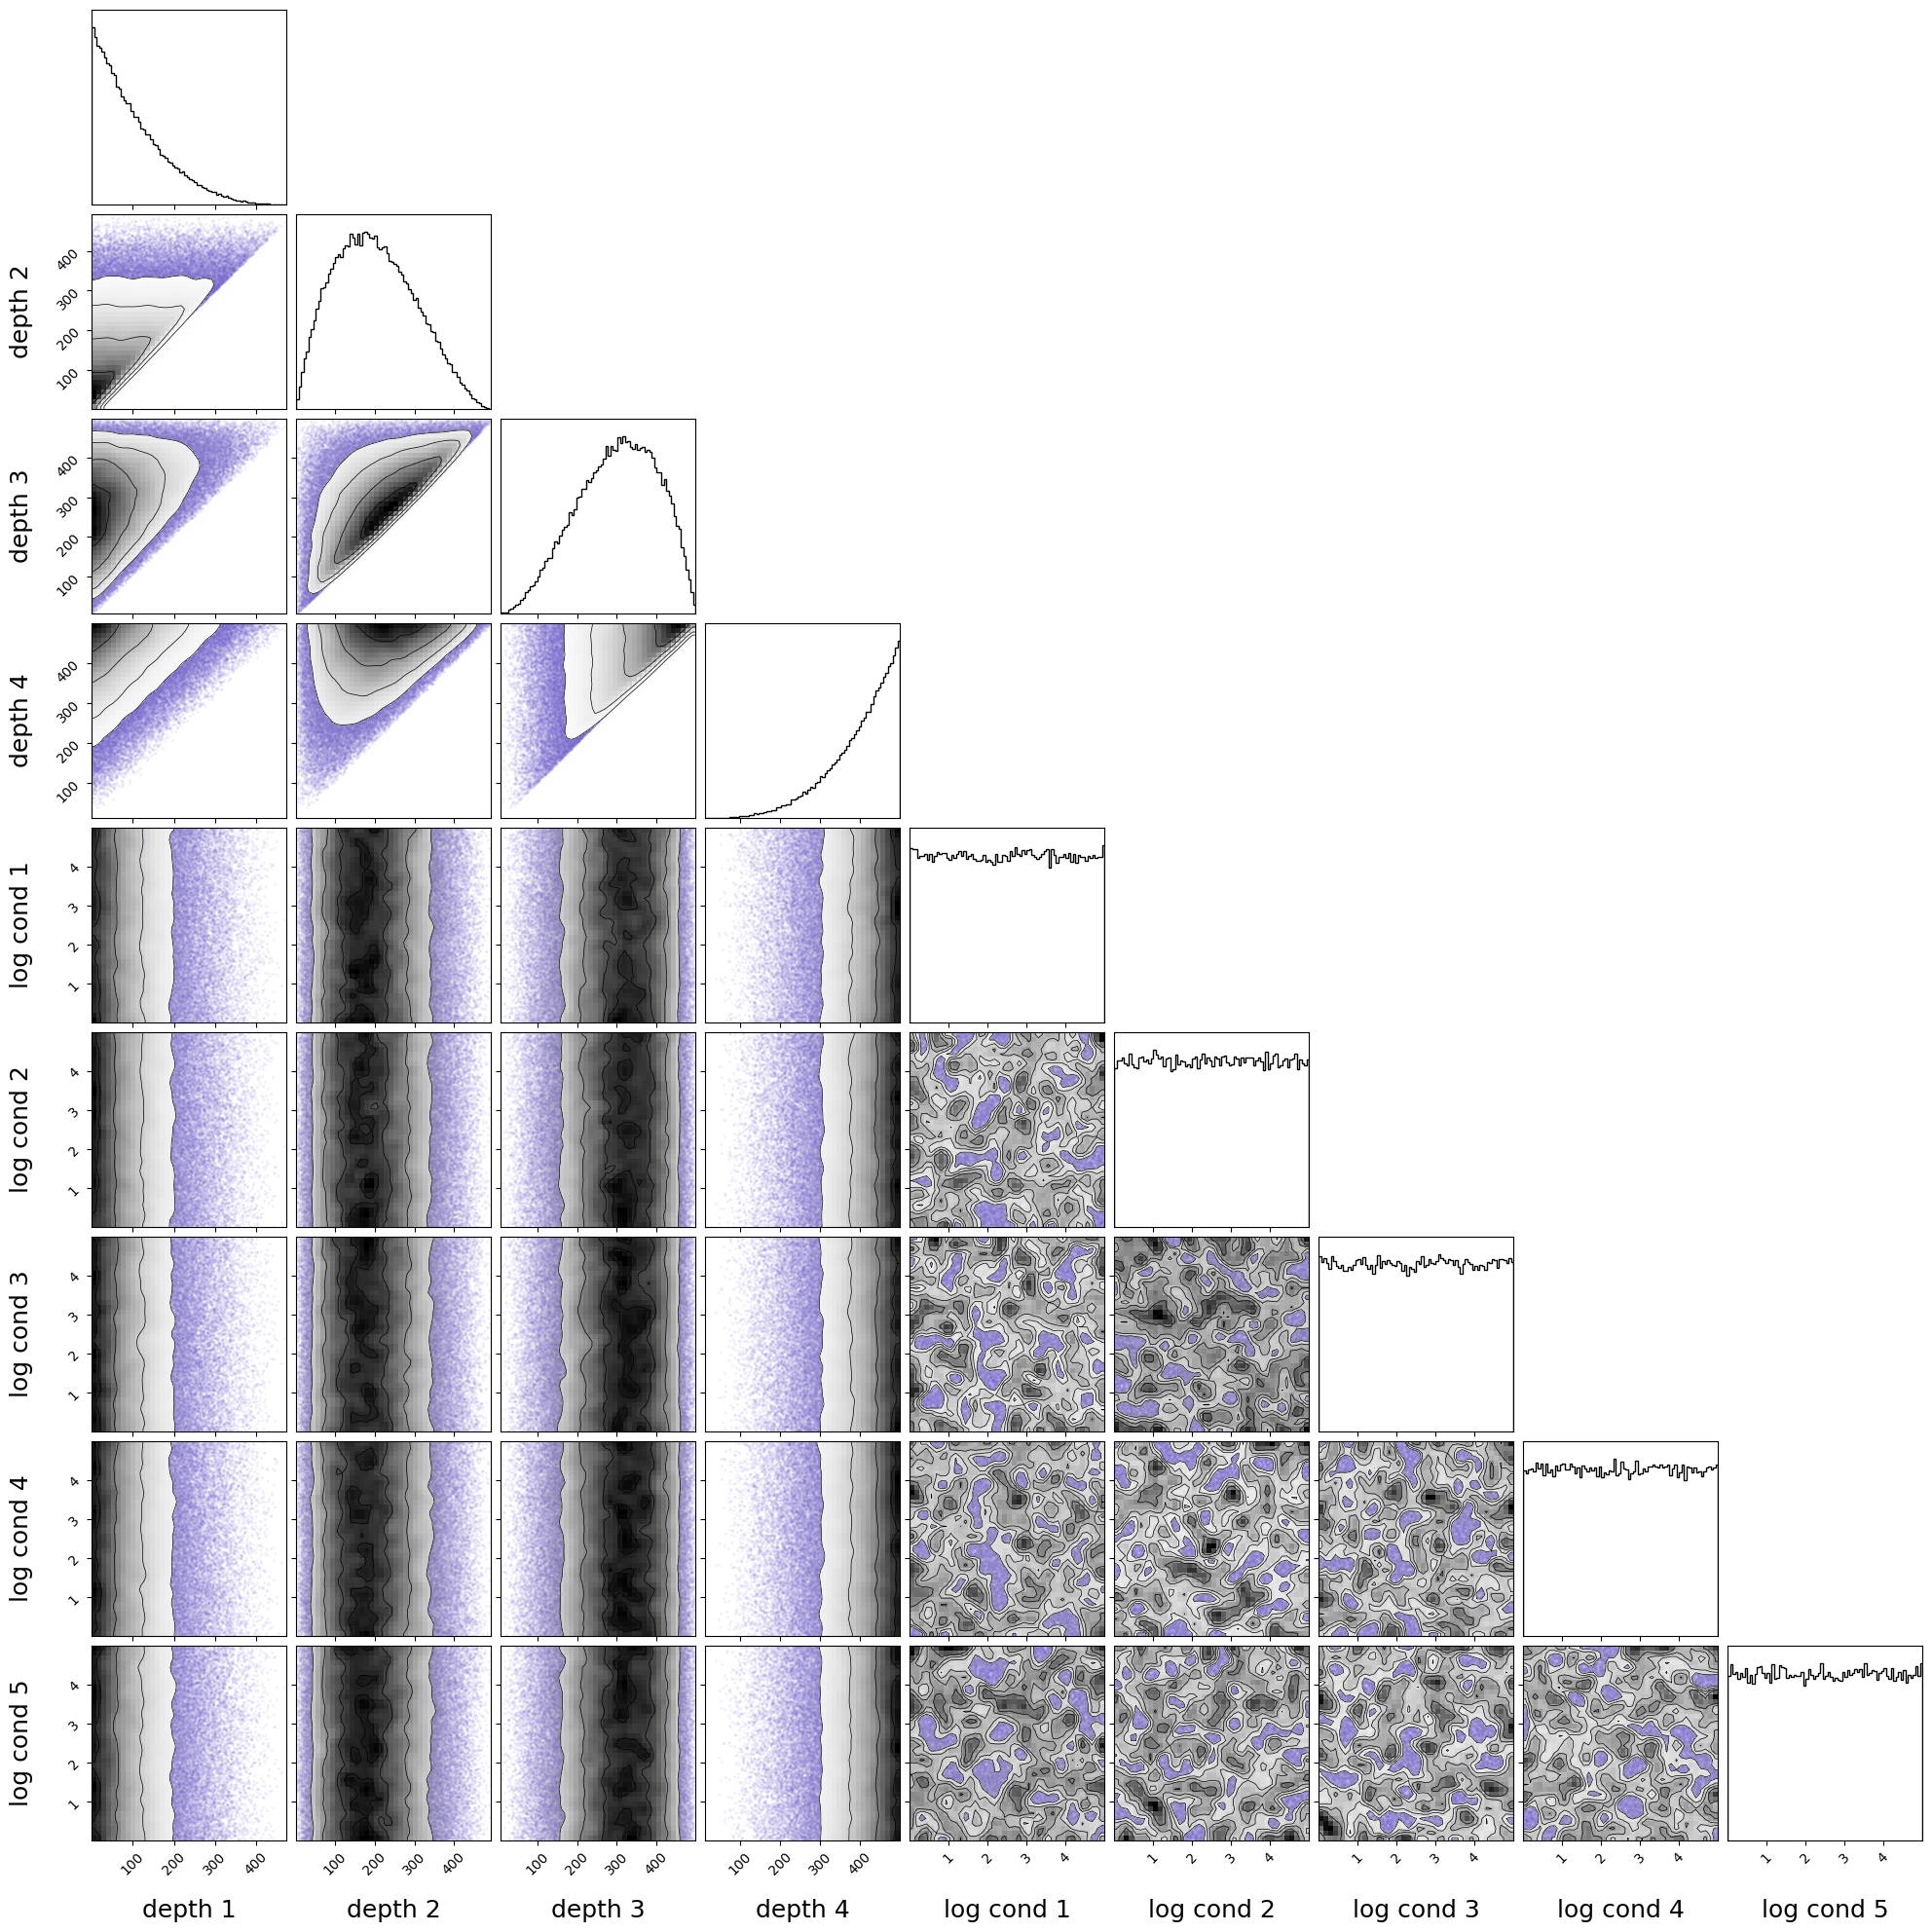

In [10]:
state = 4
label_kwargs = {"fontsize": 18}
plot_pseudo_samples(
    pseudo_prior_plot_function,
    state,
    ndims,
    ns=100000,
    truths=None,
    params=None,
    filename="AEM_priorsamples_corner_" + str(state) + ".pdf",
    label_kwargs=label_kwargs,
)  # generates and plots samples from the pseudo_prior generating function

If `pseudoprior="user"` then the pseudo prior function is a simple constant within prior bounds.

If `pseudoprior="auto"` then the pseudo prior function is calculated with the utility routine `build_auto_pseudo_prior` which, here, fits a 2 component Gaussian Mixture model to the input samples. Note that this produces a low order approximation of the input distribution shown above.

Since the plot is displayed in depth ranked order, the labels for each state become conditional on each other. This means that when samples are plotted as function of their layer depth they appear non-uniform, and are restricted to the triangular region $z_{i+1} > z_i$.

While the automatic pseudo prior build shows samples that have much more structure and approximate the input posterior samples. The ratio of densities between states is such that almost no mixing occurs between states, which demonstrates the difficulty in choosing pseudo-priors.

--------

#### Run Ensemble Resampler across states

In [11]:
# Calculate marginal Likelihoods using ensembles for each state
nwalkers = 32    # number of independent random walkers across ensembles
nsteps = 500000  # number of chain steps for each walker
start_time = time.time()
stateproposalweights = setproposalweights(
    nstates, -1
)  # set the number of neighbour states to focus transition proposals (-1 gives equal transition probability between all states)

resampler_chains = run_ensemble_resampler(
    nwalkers,
    nsteps,
    nstates,
    ndims,
    progress=True,
    log_posterior_ens=log_posterior_ens,
    log_pseudo_prior_ens=log_pseudo_prior_ens,
    state_proposal_weights=stateproposalweights,
)  # run mcmc sampler over ensembles to get marginal Likelihoods between states
elapsed_time = time.time() - start_time

2025-12-05 12:31:34 [INFO] pytransc.samplers.ensemble_resampler: 
Running ensemble resampler
2025-12-05 12:31:34 [INFO] pytransc.samplers.ensemble_resampler: 
Number of walkers               : 32
2025-12-05 12:31:34 [INFO] pytransc.samplers.ensemble_resampler: Number of states being sampled  : 10
2025-12-05 12:31:34 [INFO] pytransc.samplers.ensemble_resampler: Dimensions of each state        : [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [01:11<00:00,  2.24s/it]


#### Diagnostics

In [12]:
alg = "TransC-ensemble-resampler"
state_chain_tot = np.swapaxes(resampler_chains.state_chain_tot, 0, 1)
state_chain = resampler_chains.state_chain.T
accept_within_per_walker = 1.0 * np.ones(nwalkers)
accept_between_per_walker = resampler_chains.n_accepted / nsteps
accept_within = 100 * np.mean(accept_within_per_walker)
accept_between = 100 * np.mean(accept_between_per_walker)
nsamples = [len(a) for a in log_posterior_ens]

# extract trans-D samples and chains
discard = 0  # chain burnin
thin = 15  # chain thinning
visits, states_chain = get_visits_to_states(
    transc_sampler=resampler_chains,
    discard=discard,
    thin=thin,
    normalize=True,
)
visits = visits.swapaxes(0, 1)  # (n_steps, n_walkers, n_states)
states_chain = states_chain.swapaxes(0, 1)  # (n_steps, n_walkers)

state_changes_per_walker              = count_state_changes(resampler_chains.state_chain, discard=discard, thin=thin)
total_state_changes                   = count_total_state_changes(resampler_chains.state_chain, discard=discard, thin=thin)
acceptance_rate_between_states        = get_acceptance_rate_between_states(resampler_chains, discard=discard, thin=thin)
autocorr_time_for_between_state_jumps = get_autocorr_between_state_jumps(resampler_chains.state_chain)
relative_marginal_likelihoods         = get_relative_marginal_likelihoods(resampler_chains.state_chain_tot[:, -1, :])

print("\n Algorithm type                                      :", alg)
print(" Number of walkers                                   :", nwalkers)
print(" Number of steps                                     :", nsteps)
print(
    " Average % acceptance rate for between states        :",
    np.round(accept_between, 2),
)
print(
    " Average % acceptance rate for within states         :",
    np.round(accept_within, 2),
)
print(
    " Auto correlation time for between state sampling    :",
    np.round(autocorr_time_for_between_state_jumps, 5),
)
print(
    " Total number of state changes for all walkers       :",
    total_state_changes,
)
print(
    " Estimated relative evidences ens                    :",
    *np.round((relative_marginal_likelihoods), 5),
)
print(
    " Elapsed time                                        :",
    np.round(elapsed_time, 2),
    "s \n",
)


 Algorithm type                                      : TransC-ensemble-resampler
 Number of walkers                                   : 32
 Number of steps                                     : 500000
 Average % acceptance rate for between states        : 21.62
 Average % acceptance rate for within states         : 100.0
 Auto correlation time for between state sampling    : 8.89055
 Total number of state changes for all walkers       : 827512
 Estimated relative evidences ens                    : 0.0 0.0 0.00098 0.03873 0.09427 0.12215 0.17119 0.1886 0.19148 0.19261
 Elapsed time                                        : 71.61 s 



#### Posterior evidence for each state

We calculate the number of visits to each state which approximates the posterior evidence.
A comparison can be made with the result using Reversible-Jump MCMC equiavlent found with [Ross Brodie's Reversible-Jump MCMC code](https://github.com/GeoscienceAustralia/ga-aem)

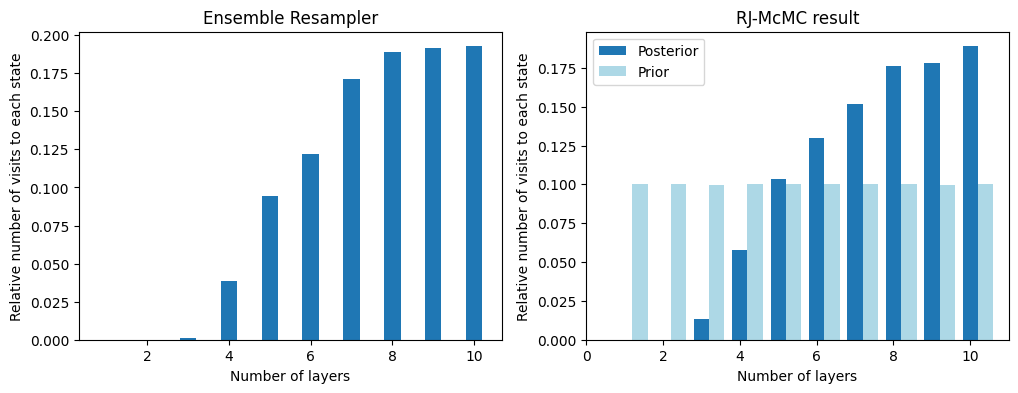

In [13]:
# Comparison of Trans-C sampler and Rj-MCMC result
plotsingle = False # type of plot Either just posterior evidence from Trans_C (True) or comparison with Rj-MCMC equivalent(False)
if(plotsingle):
    plt.figure(figsize=(6, 4))
    plt.bar(np.arange(11)[1:], relative_marginal_likelihoods)
    plt.title("Ensemble Resampler")
    plt.xlabel("Number of layers")
    plt.ylabel("Relative number of visits to each state")
    plt.savefig("AEM_posterior_histogram_10.pdf")
    plt.show()
else:
    visits_prior_rjmcmc = np.array([0.10008,0.10004,0.09992,0.10004,0.09994,0.10003,0.10004,0.10004,0.09992,0.09996])
    visits_post_rjmcmc = np.array([   0,    0,  335, 1449, 2585, 3254, 3796, 4401, 4459, 4721])
    relative_marginal_likelihoods_rjmcmc = visits_post_rjmcmc/np.sum(visits_post_rjmcmc)
    figsize = (12, 4)
    plotpair, width = True, 0.4
    fig,ax = plt.subplots(1,2,figsize=figsize)
    if plotpair:
        ax[1].bar(
        np.arange(11)[1:],
        relative_marginal_likelihoods_rjmcmc,
        width=width,
        label="Posterior",
        )
        ax[1].bar(
            np.arange(11)[1:] + width,
            visits_prior_rjmcmc,
            width=width,
            label="Prior",
            color="lightblue",
        )
    else:
        width = 0.8
        ax[1].bar(
            np.arange(11)[1:],
            relative_marginal_likelihoods_rjmcmc,
            width=width,
            label="Posterior",
        )

    ax[1].set_xlabel("Number of layers")
    ax[1].set_xlim((0, 11))
    ax[1].set_ylabel("Relative number of visits to each state")
    ax[1].set_title("RJ-McMC result")
    ax[1].legend()
    ax[0].bar(np.arange(11)[1:], relative_marginal_likelihoods, width=width)
    ax[0].set_title("Ensemble Resampler")
    ax[0].set_xlabel("Number of layers")
    ax[0].set_ylabel("Relative number of visits to each state")

plt.savefig("AEM_posterior_histogram_10.pdf")
plt.show()

A plot of the posterior sampling over states compared to the uniform prior.

#### Generate a trans-D ensemble

Here we generate a ensemble across the states from the Ensemble Resampler and compare the model density to a previously run Trans-D code using reversible-jump MCMC.

In [14]:
transd_ensemble = resample_ensembles(
    ensemble_per_state,
    relative_marginal_likelihoods,
    100_000,
)

In [15]:
# fancy density plot properties
pcentiles = [
    [5, 50, 90],           # percentile curves to plot on top of density plot
    ["r", "c", "r"],       # colours of percentile curves
    [0.4, 1.0, 0.4]]       # line widths of percentile curves
interfaceplotcolor = "C0"  # add an interface density plot with this colour of fill
cmap = "gray_r"            # colour map of density plot
log = True                 # use log(density) for colour map (T/F)
density_cutoff = 2         # relative density percentage below which to white out (makes plot prettier)

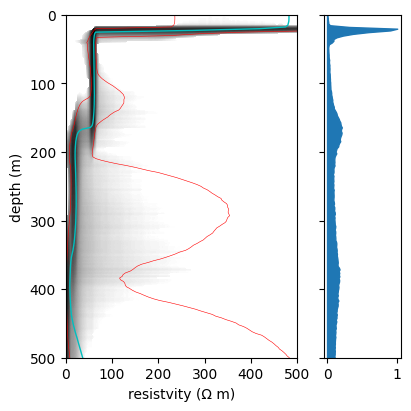

In [16]:
den = plot_histogram_is(
    transd_ensemble,
    0,
    500,
    100,
    0,
    500,
    200,  # fancy density plot
    figsize=(4, 4),
    cmap=cmap,
    log=log,
    density_cutoff=density_cutoff,
    pcentiles=pcentiles,
    interfaceplotcolor=interfaceplotcolor,
    filename="AEM_densityprofile_10.pdf",
)

Note that the Ensemble Resampler solution required a pre-compute of posteriors samples within each state, but after that no further forward modelling is required and hence a much larger number of steps can be performed in the resampling stage, $5\times10^5$ in this case, which leads to the smoother histograms seen above.

Here is the result using Reversible-Jump MCMC found with [Ross Brodie's Reversible-Jump MCMC code](https://github.com/GeoscienceAustralia/ga-aem)

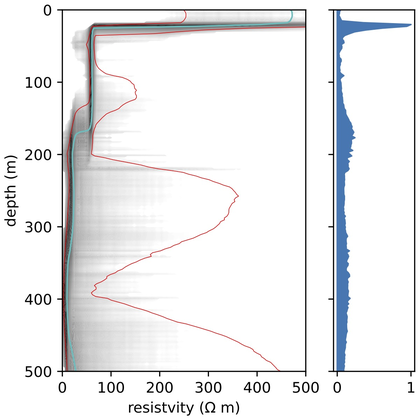

In [17]:
img = Image.open("./AEM_data/rjmcmc_densityprofile.jpg")
display(img.resize((420, 420), Image.LANCZOS))

The two solutions are very similar. 